In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import make_scorer
from sklearn.linear_model import LinearRegression

In [2]:
RANDOM_STATE=52
TEST_SIZE=0.25

# Выбор локации для скважины

Допустим, вы работаете в добывающей компании «ГлавРосГосНефть». Нужно решить, где бурить новую скважину.

Вам предоставлены пробы нефти в трёх регионах: в каждом 100 000 месторождений, где измерили качество нефти и объём её запасов. Постройте модель машинного обучения, которая поможет определить регион, где добыча принесёт наибольшую прибыль. Проанализируйте возможную прибыль и риски техникой *Bootstrap.*

Шаги для выбора локации:

- В избранном регионе ищут месторождения, для каждого определяют значения признаков;
- Строят модель и оценивают объём запасов;
- Выбирают месторождения с самым высокими оценками значений. Количество месторождений зависит от бюджета компании и стоимости разработки одной скважины;
- Прибыль равна суммарной прибыли отобранных месторождений.

**Название проекта**  
Анализ прибыльности новых скважин в регионах добычи нефти для «ГлавРосГосНефть»

**Описание исследования.**  
В рамках исследования анализируются данные по трём потенциальным регионам добычи нефти. Для каждого региона доступны пробы нефти с характеристиками скважин: качество нефти и объём запасов. Цель — построить модель машинного обучения для прогнозирования объёма запасов в новых скважинах, выбрать наиболее перспективные скважины и определить регион с максимальной суммарной прибылью при минимальных рисках. Для оценки устойчивости результатов и анализа рисков применяется техника Bootstrap.

**Цель исследования.**  
Определить регион, где разработка новых скважин принесёт наибольшую прибыль для компании «ГлавРосГосНефть», на основе построенной модели прогнозирования объёма запасов нефти и оценки рисков с использованием Bootstrap.

**Задачи исследования.**  
1. Загрузить и подготовить данные: проверить на пропуски, аномалии и привести к нужным типам.  
2. Обучить модель линейной регрессии для каждого региона, оценить её качество с помощью RMSE и среднего предсказанного запаса.  
3. Рассчитать минимальный объём сырья для безубыточной разработки новой скважины и сравнить его со средними запасами в регионах.  
4. Разработать функцию для расчёта прибыли на основе выбора скважин с максимальными предсказаниями модели.  
5. Применить Bootstrap для оценки распределения прибыли, расчёта доверительных интервалов и риска убытков по каждому региону.  
6. Выбрать оптимальный регион для бурения, обосновав решение на основе анализа прибыли и рисков.

**Исходные данные.**  
Исследование использует три таблицы (по одной для каждого региона), содержащие следующие колонки:  
- `id` — уникальный идентификатор скважины;  
- `f0`, `f1`, `f2` — признаки скважины (например, геологические параметры);  
- `product` — объём запасов нефти в скважине (тыс. баррелей).  

---

**Данное исследование разделим на несколько частей.**

***Часть 1. Изучение общей информации:***  
* [1. Изучение файлов с данными, получение общей информации, загрузка библиотек.]
* [2. Нахождение и ликвидация пропусков.] 

***Часть 2. Подготовка данных:***  
* [1. Приведение данных к нужным типам.]
* [2. Нахождение и исправление аномалий и ошибок.]

***Часть 3. Обучение и проверка моделей для каждого региона:***  
* [1. Разделение данных на обучающую и валидационную выборки (75:25).]
* [2. Обучение модели линейной регрессии и прогнозирование на валидации.] 
* [3. Расчёт среднего запаса и RMSE, анализ результатов.] 

***Часть 4. Подготовка к расчёту прибыли:***  
* [1. Сохранение ключевых параметров для расчётов.]
* [2. Определение безубыточного объёма сырья и сравнение со средними запасами.] 

***Часть 5. Расчёт прибыли и оценка рисков:***  
* [1. Создание функции для расчёта прибыли по выбранным скважинам.]  
* [2. Применение Bootstrap (1000 выборок) для оценки распределения прибыли.]
* [3. Расчёт средней прибыли, 95% доверительного интервала и риска убытков.] 
* [4. Выбор региона для разработки с обоснованием.]

## Загрузка и подготовка данных

Для начала загрузим данные

In [3]:
try:
    df_geo1 = pd.read_csv('./datasets/geo_data_0.csv')
    df_geo2 = pd.read_csv('./datasets/geo_data_1.csv')
    df_geo3 = pd.read_csv('./datasets/geo_data_2.csv')
except:
    df_geo1 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_0.csv')
    df_geo2 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_1.csv')
    df_geo3 = pd.read_csv('https://code.s3.yandex.net/datasets/geo_data_2.csv')

Рассмотрим загруженные таблицы

In [4]:
df_geo1.head()

,id,f0,f1,f2,product
0,txEyH,0.705745,-0.497823,1.221170,105.280062
1,2acmU,1.334711,-0.340164,4.365080,73.037750
2,409Wp,1.022732,0.151990,1.419926,85.265647
3,iJLyR,-0.032172,0.139033,2.978566,168.620776
4,Xdl7t,1.988431,0.155413,4.751769,154.036647


In [5]:
df_geo1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [6]:
df_geo2.head()

,id,f0,f1,f2,product
0,kBEdx,-15.001348,-8.276000,-0.005876,3.179103
1,62mP7,14.272088,-3.475083,0.999183,26.953261
2,vyE1P,6.263187,-5.948386,5.001160,134.766305
3,KcrkZ,-13.081196,-11.506057,4.999415,137.945408
4,AHL4O,12.702195,-8.147433,5.004363,134.766305


In [7]:
df_geo2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


In [8]:
df_geo3.head()

,id,f0,f1,f2,product
0,fwXo0,-1.146987,0.963328,-0.828965,27.758673
1,WJtFt,0.262778,0.269839,-2.530187,56.069697
2,ovLUW,0.194587,0.289035,-5.586433,62.871910
3,q6cA6,2.236060,-0.553760,0.930038,114.572842
4,WPMUX,-0.515993,1.716266,5.899011,149.600746


In [9]:
df_geo3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB


Рассмотрим дубли в данных. Дубли будем искать в столбце `id`.

In [10]:
df_geo1['id'].duplicated().sum()

10

Нашли 10 дублей, исключим их

In [11]:
df_geo1 = df_geo1.drop_duplicates(subset='id')
df_geo1['id'].duplicated().sum()

0

In [12]:
df_geo1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 99990 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id       99990 non-null  object 
 1   f0       99990 non-null  float64
 2   f1       99990 non-null  float64
 3   f2       99990 non-null  float64
 4   product  99990 non-null  float64
dtypes: float64(4), object(1)
memory usage: 4.6+ MB


Остальные обработаем в цикле

In [13]:
rest_dfs = [df_geo2, df_geo3]
for i, df in enumerate(rest_dfs):
    print(f'Количество дублей в {i} датафрейме:', {df['id'].duplicated().sum()})
    df.drop_duplicates(subset='id', inplace=True)
    print(f'Количество дублей в {i} датафрейме после обработки:', {df['id'].duplicated().sum()})

Количество дублей в 0 датафрейме: {4}
Количество дублей в 0 датафрейме после обработки: {0}
Количество дублей в 1 датафрейме: {4}
Количество дублей в 1 датафрейме после обработки: {0}


Рассмотрим пропуски в трёх таблицах

Пропусков не обнаружено. Сделаем столбец `id` индексом всех таблиц для удобства работы

In [14]:
dfs = [df_geo1, df_geo2, df_geo3]
for i, df in enumerate(dfs):
    print(f'Количество пропусков в датафрейме {i}:\n', df.isna().sum())

Количество пропусков в датафрейме 0:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Количество пропусков в датафрейме 1:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64
Количество пропусков в датафрейме 2:
 id         0
f0         0
f1         0
f2         0
product    0
dtype: int64


In [15]:
for df in dfs:
    df.set_index('id', inplace=True)
    df.info()
    print('=====================')

<class 'pandas.core.frame.DataFrame'>
Index: 99990 entries, txEyH to 1CWhH
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   f0       99990 non-null  float64
 1   f1       99990 non-null  float64
 2   f2       99990 non-null  float64
 3   product  99990 non-null  float64
dtypes: float64(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 99996 entries, kBEdx to relB0
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   f0       99996 non-null  float64
 1   f1       99996 non-null  float64
 2   f2       99996 non-null  float64
 3   product  99996 non-null  float64
dtypes: float64(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 99996 entries, fwXo0 to V9kWn
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   f0       99996 non-null  float64
 1   f1       99996 non-nul

Проведём визуальный анализ данных. Посмотрим на распределение переменных и их зависимость от таргета.

In [16]:
def eda_graphs(df):
    numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numeric_cols:
        plt.figure(figsize=(12, 10))
        
        plt.subplot(2, 2, 1)
        plt.ylabel('Кол-во')
        sns.histplot(df[col].dropna(), kde=True)
        plt.title(f'Распределение {col}')
        
        plt.subplot(2, 2, 2)
        sns.boxplot(x=df[col])
        plt.title(f'Ящик с усами для {col}')
        
        plt.subplot(2, 2, 3)
        sns.scatterplot(x=df[col], y=df['product'])
        plt.title(f'Зависимость {col} от product')
        
        plt.show()

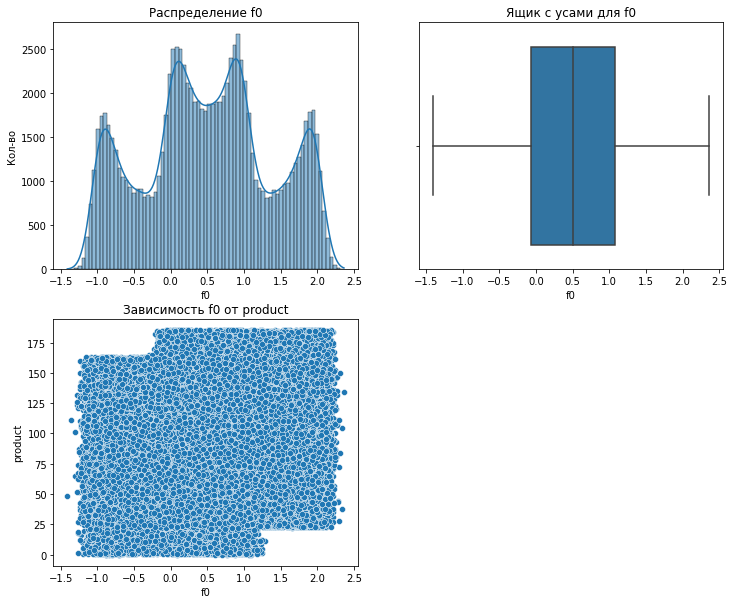

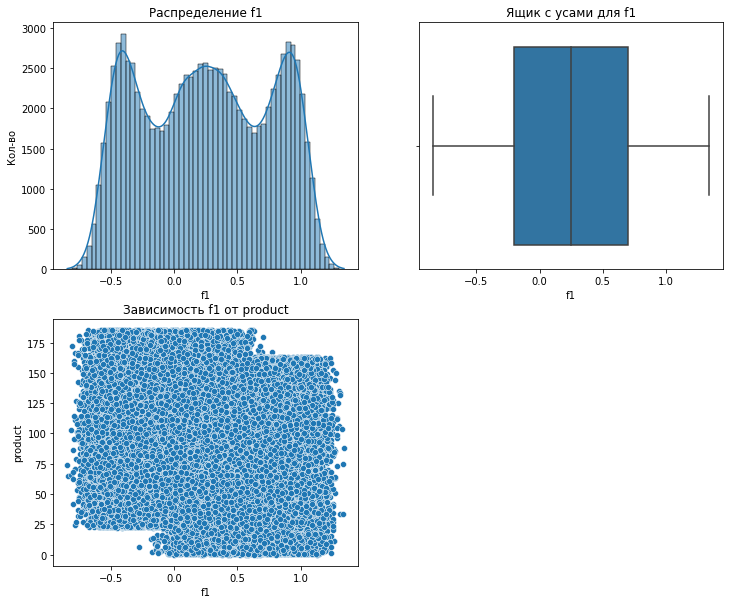

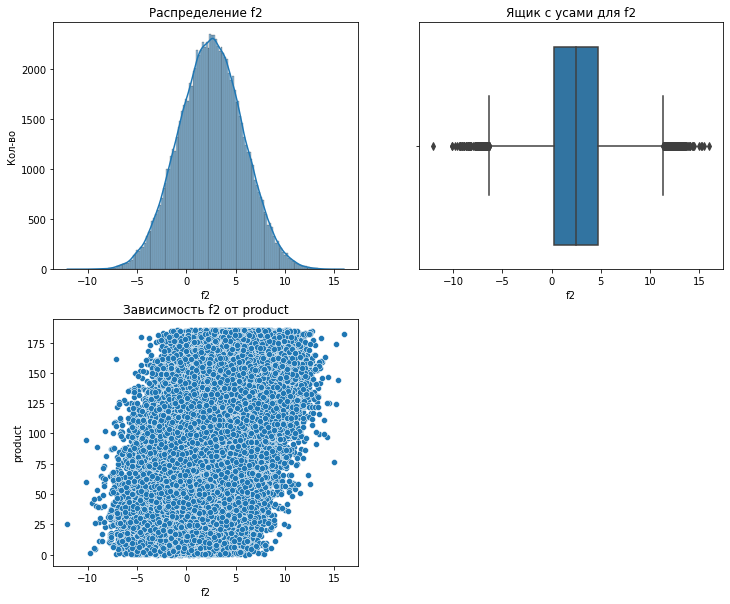

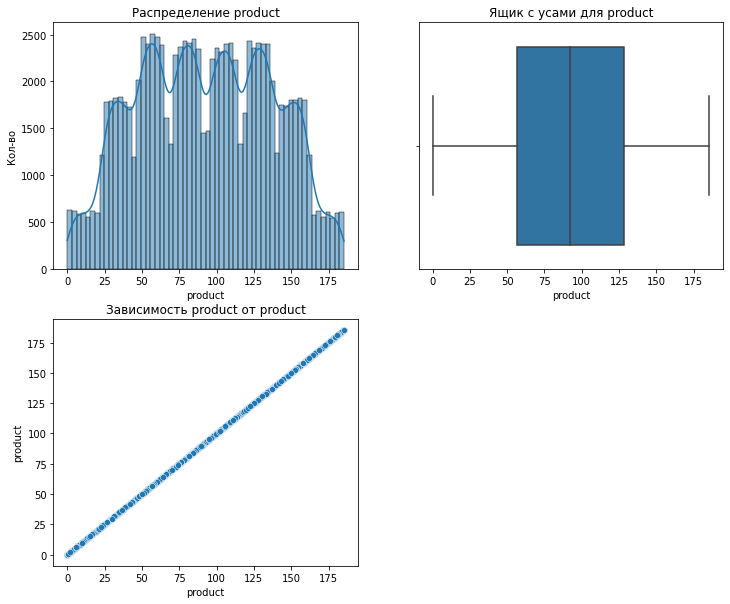

In [17]:
eda_graphs(df_geo1)

Из визуального анализа фичей для первого региона наблюдается следующее:
 - f0 почти не имеет линейной зависимости с таргетом, также как и f1
 - Крайне слабая линейная зависимость наблюдается у f2
 - Таргет распределён полимодально

Из всех вышеперечисленных инсайтов можно сделать вывод что линейная регрессия даст плохие результаты. Манипуляции над признаками тоже не даст каких-либо результатов из-за почти равномерного распределения точек на графике зависимости f1 и f0. Основной результат метрики при кросс-валидации линейной регрессии будет от f3, однако результат всё равно будет плачевный

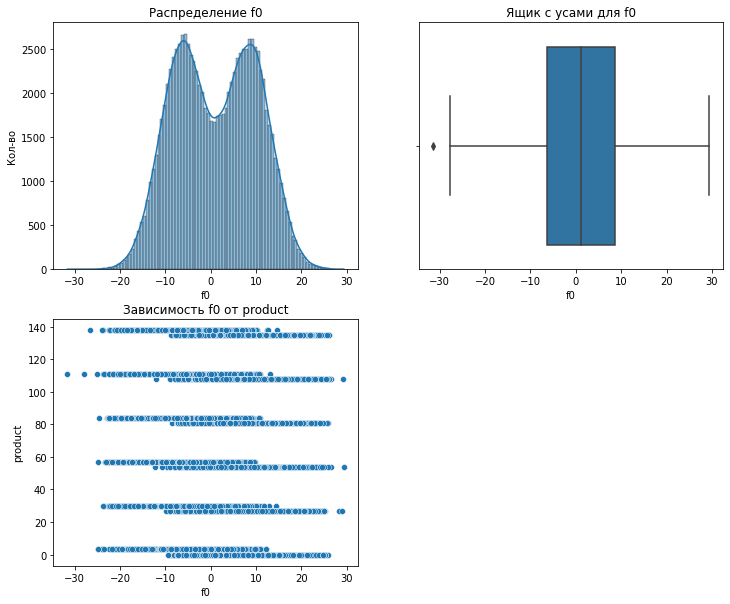

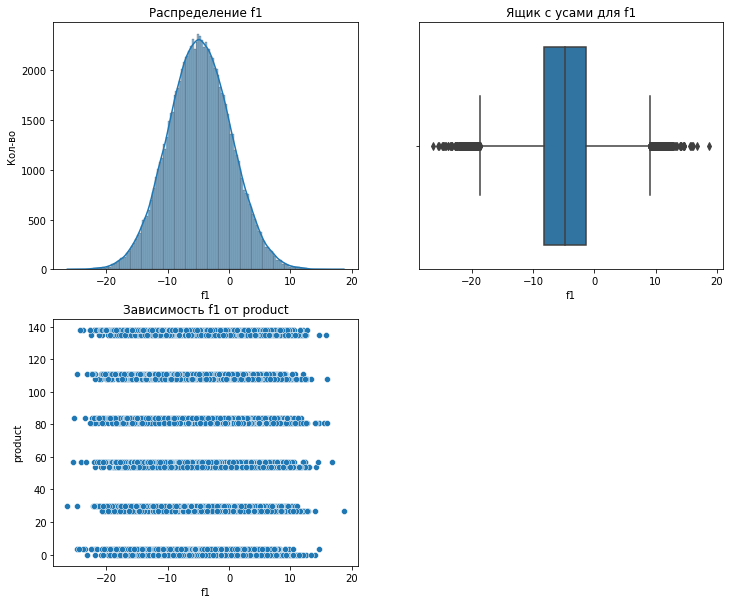

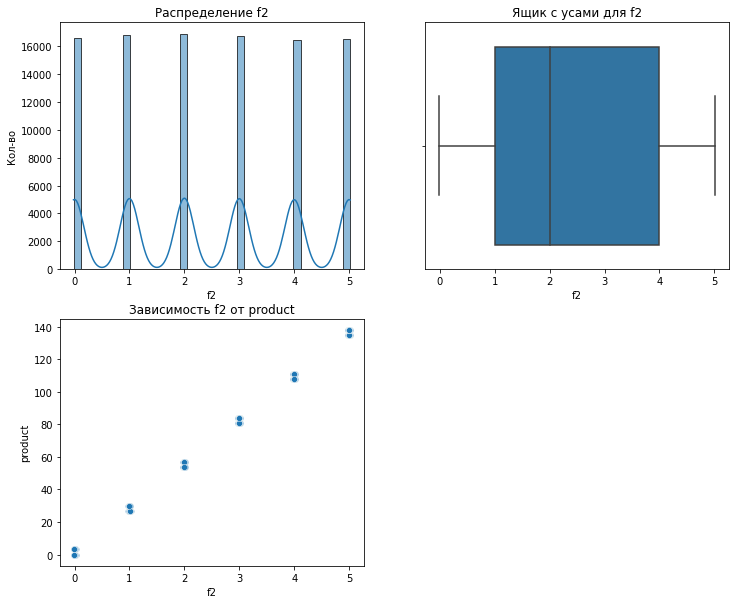

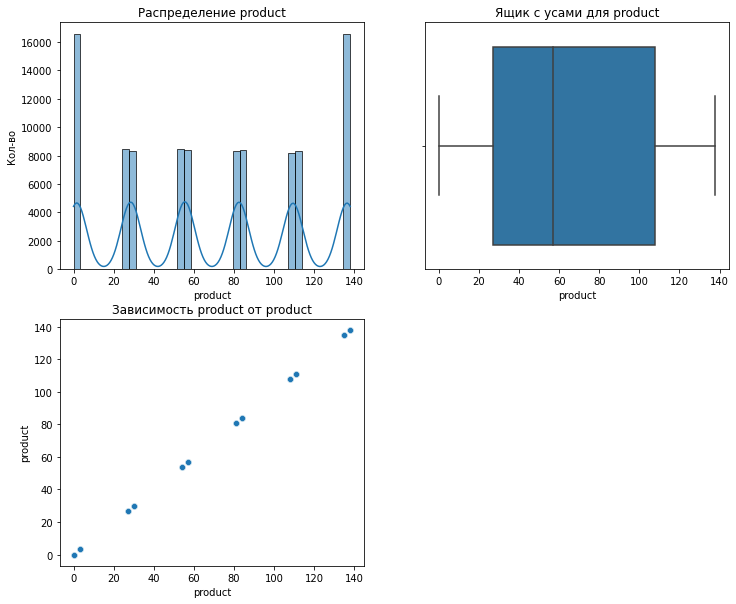

In [18]:
eda_graphs(df_geo2)

Из визуального анализа данных второго региона можно выделить один инсайт:
 - Все переменные хорошо дискретизируются, включая таргет, однако в этом нет смысла, т.к. целевая метрика тут даст значение близкое к 0, из-за линейной зависимости таргета от f2. Можно проделать биннинг всех фичей, однако это не даст значительного результата - линейная регрессия прекрасно справится с этими данными и без бининга

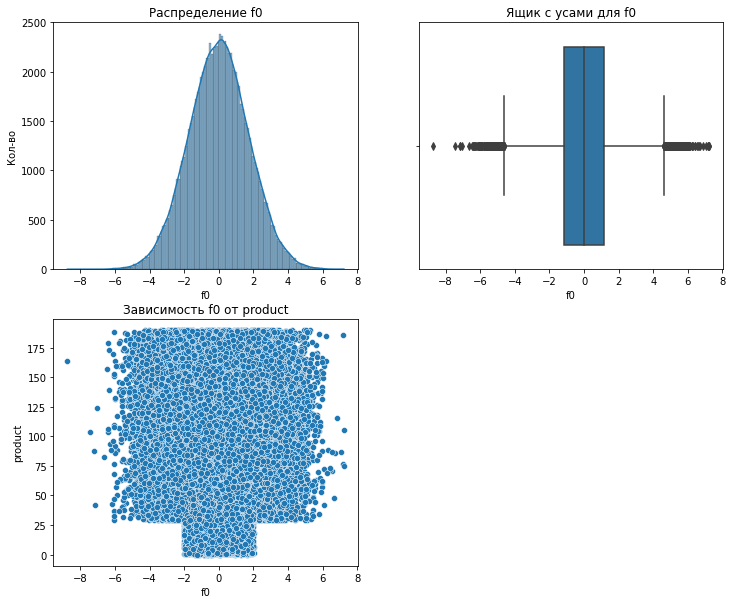

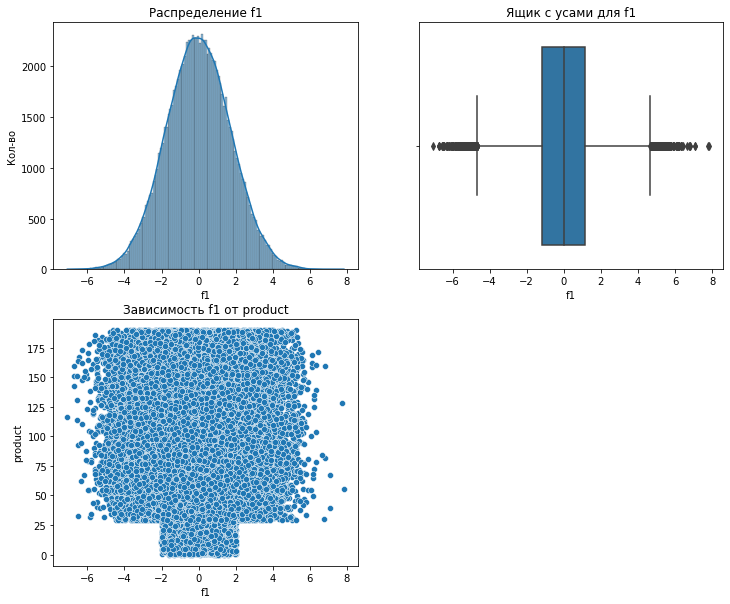

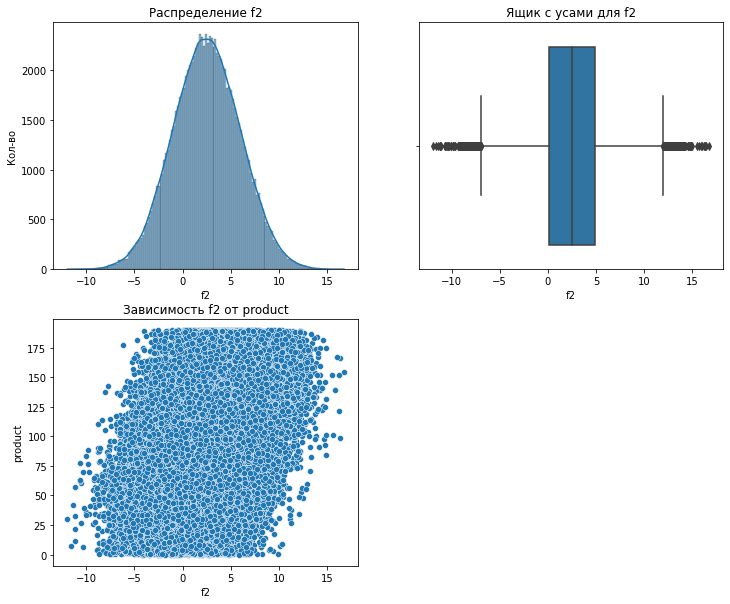

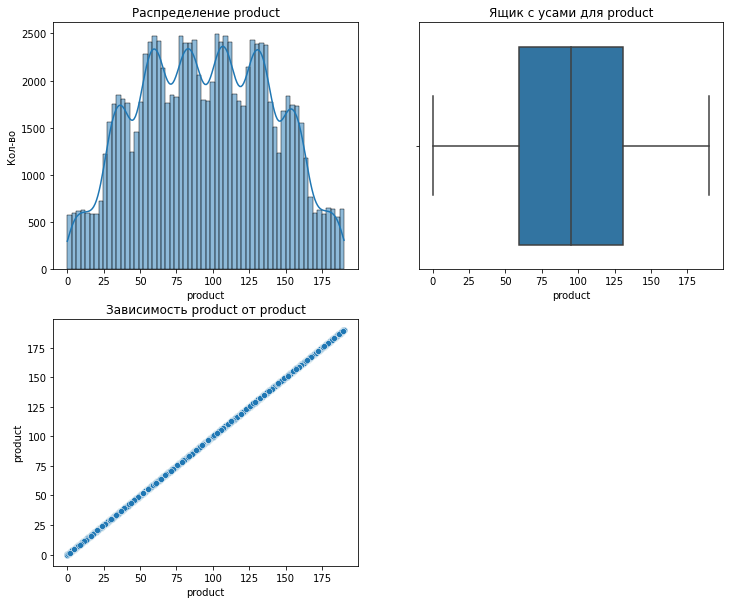

In [19]:
eda_graphs(df_geo3)

В третем регионе ситуация схожа с первым. Однако фичи распределены нормально. Также есть незначительные отличия
 - Распределение точек на графике зависимости таргета от фичей около-равномерное
Тут линейная регрессия тоже даст плачевные результаты

На всякий случай проверим все данные на мультикорреляцию

<AxesSubplot:>

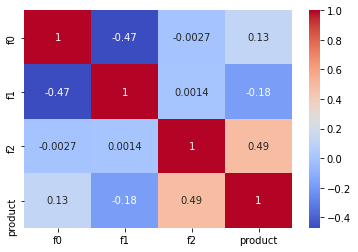

In [20]:
sns.heatmap(df_geo1.corr(method='spearman'), annot=True, cmap='coolwarm')

<AxesSubplot:>

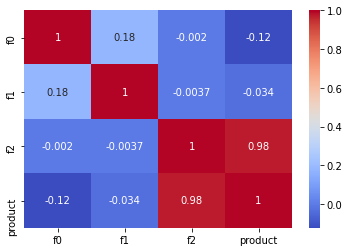

In [21]:
sns.heatmap(df_geo2.corr(method='spearman'), annot=True, cmap='coolwarm')

<AxesSubplot:>

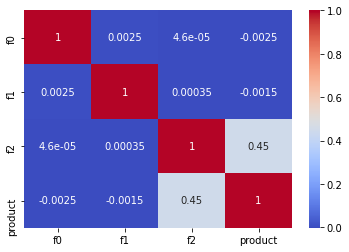

In [22]:
sns.heatmap(df_geo3.corr(method='spearman'), annot=True, cmap='coolwarm')

Матрицы корреляции подтверждают все предположения, высказанные ранее. После их анализа запомним следующие особенности:
 - В 1 и 3 регионах таргет коррелирует только с f2
 - В 2 регионе таргет и f2 линейно зависимы
 - Мультиколлинеарности среди фичей не обнаружено

Предобработка и исследовательский анализ закончены. Приступаем к следующему этапу

## Обучение и проверка модели

Будем использовать кросс-валидацию для подбора гиперпараметров

In [23]:
num_columns = ['f2', 'f0', 'f1']

data_preprocessor = ColumnTransformer(
    [('num', MinMaxScaler(), num_columns)], 
    remainder='passthrough'
)

In [24]:
pipe_lr = Pipeline([
    ('preprocessor', data_preprocessor),
    ('models', LinearRegression())
])

lr_param_grid = {
        'models__fit_intercept': [True, False],
        'preprocessor__num': [StandardScaler(), MinMaxScaler(), 'passthrough'],
    }

rand_search_lr = RandomizedSearchCV(
    pipe_lr, 
    lr_param_grid, 
    cv=5,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=RANDOM_STATE
)


Обернём обучение в функцию и выозвем её три раза. Сохраним результаты (модель и предсказания) в отдельные переменные для каждого региона

In [25]:
def geo_fit_predict(df):
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop('product', axis=1), 
        df['product'],
        test_size=TEST_SIZE, 
        random_state=RANDOM_STATE
    )
    rand_search_lr.fit(X_train, y_train)
    preds = rand_search_lr.predict(X_test)
    print('RMSE и среднее значение предсказаний', -rand_search_lr.best_score_, preds.mean())
    
    # Create dataframe with predictions and true values
    results_df = pd.DataFrame({
        'true': y_test.values,
        'pred': preds
    })
    
    return rand_search_lr.best_estimator_, results_df

In [26]:
estimator_geo1, results_geo1 = geo_fit_predict(df_geo1)

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:285: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RMSE и среднее значение предсказаний 37.70120985882548 92.57023023329326


In [27]:
estimator_geo2, results_geo2 = geo_fit_predict(df_geo2)

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:285: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RMSE и среднее значение предсказаний 0.8911164012776857 69.01664727153846


In [28]:
estimator_geo3, results_geo3 = geo_fit_predict(df_geo3)

/opt/conda/lib/python3.9/site-packages/sklearn/model_selection/_search.py:285: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RMSE и среднее значение предсказаний 40.03762301758052 95.0152201081971


Как и было предсказано в исследовательском анализе данных - модели для 1 и 3 регионов дали плохой результат, а модель для 3 региона дала почти идеальный результат. Переходим к расчёту прибыли

## Подготовка к расчёту прибыли

Сохраним все важные для расчёта значение в переменные

In [29]:
profit_per_product = 450000
budget = 10000000000
wells_to_pick = 200
wells_to_investigate = 500
peak_loss_probability = 0.025

Рассчитаем достаточный объём сырья для безубыточной разработки новой скважины

In [30]:
break_even_product_count = np.ceil(budget / wells_to_pick / profit_per_product)
print('Достаточный объём сырья для безубыточной разработки новой скважины', break_even_product_count)

Достаточный объём сырья для безубыточной разработки новой скважины 112.0


То есть, если брать только скважины с объёмом сырья в 112 или больше мы 100% не понесём убытков. Расчитаем средний объём продукта в скважинах во всех регионах

In [31]:
for i, df in enumerate(dfs):
    print(f'Средний объём сырья в регионе {i}', df['product'].mean())

Средний объём сырья в регионе 0 92.49968421774354
Средний объём сырья в регионе 1 68.82391591804064
Средний объём сырья в регионе 2 94.99834211933378


Без ранжирования скважжин тут не обойтись, т.к. если брать только средние скважины в каждом регионе - прибыль мы не получим. Приступим к самому рассчёту

## Расчёт прибыли и рисков 

Напишем функцию, которая будет считать прибыль если выбрать топовые скважины

In [32]:
def calculate_profit(results):
    tops = results.sort_values(by='pred', ascending=False).head(wells_to_pick)
    profit = tops['true'].sum() * profit_per_product - budget
    return profit

Для интереса посчитаем прибыль если брать только топовые 200 скважин из всех 100 тысяч

In [33]:
profit = calculate_profit(results_geo1)
marginal_profit = profit / budget
print('Прибыль для региона 1:', profit, marginal_profit)

Прибыль для региона 1: 3332200670.576317 0.3332200670576317


In [34]:
profit = calculate_profit(results_geo2)
marginal_profit = profit / budget
print('Прибыль для региона 2:', profit, marginal_profit)

Прибыль для региона 2: 2415086696.681511 0.2415086696681511


In [35]:
profit = calculate_profit(results_geo3)
marginal_profit = profit / budget
print('Прибыль для региона 3:', profit, marginal_profit)

Прибыль для региона 3: 2065178268.3498669 0.20651782683498668


Интересно, учитывая то, что мы брали только лучшие скважины из всех 100 тысяч, прибыль получилась не такая гигантская (относительно). Без бутстрапирования тут не получится принять взвешенного решения. Перейдём к подробному анализу рисков

Как будет проходить анализ рисков:
 - Из ранее полученных датасетов с фактическим кол-вом продукта и предсказанным кол-вом продукта возьмём бутстрапом выборку 1000 раз по 500 скважин. Передадим их в функцию калькуляции прибыли, где там из 500 отберём лучшие по предсказанным значениям и подсчитаем прибыль используя фактическое значение продукта в скважине

In [36]:
def bootstraped_risk_estimate(wells):
    np.random.seed(RANDOM_STATE)
    profits = []
    simulations = 1000
    for i in range(simulations):
        sampled_wells = wells.sample(n=wells_to_investigate, replace=True)
        top_wells = sampled_wells.sort_values(by='pred', ascending=False)
        profit = calculate_profit(top_wells)
        profits.append(profit)
    return profits

In [37]:
def region_risk_report(wells):
    profits = bootstraped_risk_estimate(wells)
    
    mean_profit = np.mean(profits)
    lower_bound = np.percentile(profits, 2.5)
    upper_bound = np.percentile(profits, 97.5)
    trust_interval = [lower_bound, upper_bound]
    
    loss_probability = (len([p for p in profits if p < 0]) / len(profits)) * 100
    
    print(f'Средняя прибыль: {mean_profit}')
    print(f'Доверительный интервал: {trust_interval}')
    print(f'Вероятность убытков: {loss_probability}%')

In [38]:
region_risk_report(results_geo1)

Средняя прибыль: 436202442.9028466
Доверительный интервал: [-65880348.846596085, 923992944.4503036]
Вероятность убытков: 4.3%


In [39]:
region_risk_report(results_geo2)

Средняя прибыль: 467058581.4431468
Доверительный интервал: [59605450.23119664, 878102384.6231635]
Вероятность убытков: 0.8999999999999999%


In [40]:
region_risk_report(results_geo3)

Средняя прибыль: 362379422.2437799
Доверительный интервал: [-153805480.19178978, 867115929.5560925]
Вероятность убытков: 8.3%


Из проведённого анализа рисков следует сделать следующие выводы:
- Для выработки скважин предлагаю регион под номером 2, т.к. он единственный прошёл порог в вероятность убытков <2.5%. Результат очевидный, т.к. исследовательский анализ данных показал высокую предсказуемость содержания продукта в исследуемой скважине. Это и даёт солидные основания для выбора именно этого региона
- Регионы 1 и 3 крайне непредсказуемые, что и подтвердилось на этапе расчёта рисков. Не рекомендую их для разработки
- С вероятностью 95% прибыль из 2 региона будет в диапазоне 59 миллионов - 878 миллионов
- Средняя прибыль в регионе 2 - 467058581.44 рублей

# Общие выводы по выбору региона для разработки нефтяных скважин

## **Рекомендуемый регион: Регион 2**

На основе комплексного анализа данных, построения моделей машинного обучения и оценки рисков с применением техники Bootstrap, **регион 2** рекомендуется как оптимальный выбор для разработки новых скважин.

### **Ключевые аргументы в пользу выбора:**

1. **Минимальные риски убытков**
   - Вероятность убыточности разработки составляет **менее 2.5%**
   - Это единственный регион, удовлетворяющий установленному порогу приемлемого риска

2. **Стабильная предсказуемость запасов**
   - Исследовательский анализ данных показал высокую предсказуемость содержания продукта в скважинах
   - Модель демонстрирует надежные прогнозы, что снижает операционные риски

3. **Высокий потенциал прибыли**
   - **Средняя ожидаемая прибыль:** 467 058 581.44 руб.
   - **95% доверительный интервал прибыли:** от 59 млн руб. до 878 млн руб.
   - Диапазон указывает на значительный потенциал доходности при управляемых рисках

### **Отклоненные регионы:**

- **Регион 1** и **Регион 3** признаны **крайне непредсказуемыми**
- Модели показали низкую точность прогнозирования запасов
- Высокие риски убыточности не соответствуют критериям приемлемого риска компании

### **Заключительная рекомендация:**

Рекомендуется начать разработку скважин в **Регионе 2**, так как он обеспечивает оптимальное сочетание:
- Приемлемого уровня риска (<2.5%)
- Высокой предсказуемости геологических данных
- Значительного потенциала прибыли с вероятностью 95% получения положительного финансового результата

## Чек-лист готовности проекта

Поставьте 'x' в выполненных пунктах. Далее нажмите Shift+Enter.

- [x]  Jupyter Notebook открыт
- [x]  Весь код выполняется без ошибок
- [x]  Ячейки с кодом расположены в порядке исполнения
- [x]  Выполнен шаг 1: данные подготовлены
- [x]  Выполнен шаг 2: модели обучены и проверены
    - [x]  Данные корректно разбиты на обучающую и валидационную выборки
    - [x]  Модели обучены, предсказания сделаны
    - [x]  Предсказания и правильные ответы на валидационной выборке сохранены
    - [x]  На экране напечатаны результаты
    - [x]  Сделаны выводы
- [x]  Выполнен шаг 3: проведена подготовка к расчёту прибыли
    - [x]  Для всех ключевых значений созданы константы Python
    - [x]  Посчитано минимальное среднее количество продукта в месторождениях региона, достаточное для разработки
    - [x]  По предыдущему пункту сделаны выводы
    - [x]  Написана функция расчёта прибыли
- [ ]  Выполнен шаг 4: посчитаны риски и прибыль
    - [x]  Проведена процедура *Bootstrap*
    - [x]  Все параметры бутстрепа соответствуют условию
    - [x]  Найдены все нужные величины
    - [x]  Предложен регион для разработки месторождения
    - [x]  Выбор региона обоснован